In [2]:
import json
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [3]:
ROOT = Path(".")
DATASET_DIR = ROOT / "Dataset"
CHECKPOINT_PATH = ROOT / "best_densenet121_scale224.pth"
OUTPUT_JSON_PATH = ROOT / "multi_label_annotations.json"

MULTILABEL_THRESH = 0.20
CAM_BINARY_THRESH = 0.55
MIN_AREA_PX = 400
MAX_AREA_RATIO = 0.70
CAM_PEAK_THRESH = 0.60
CROSS_CLASS_IOU_THRESH = 0.70

assert DATASET_DIR.exists(), f"Dataset directory not found: {DATASET_DIR}"
assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

CLASS_NAMES = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
assert "notumor" in CLASS_NAMES, "Expected class 'notumor' in dataset folders."
TUMOR_CLASS_NAMES = [c for c in CLASS_NAMES if c != "notumor"]
DET_LABEL_MAP = {name: idx + 1 for idx, name in enumerate(TUMOR_CLASS_NAMES)}

print("Classifier classes:", CLASS_NAMES)
print("Detector label map (1-indexed):", DET_LABEL_MAP)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def minmax_norm(tensor):
    return (tensor - tensor.min()) / (tensor.max() - tensor.min() + 1e-8)

INFER_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(minmax_norm),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229]),
])

def build_classifier(num_classes):
    model = models.densenet121(weights=None)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

def load_checkpoint(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict):
        if "state_dict" in ckpt:
            state_dict = ckpt["state_dict"]
        elif "model_state_dict" in ckpt:
            state_dict = ckpt["model_state_dict"]
        else:
            state_dict = ckpt
    else:
        state_dict = ckpt

    cleaned_state = {}
    for k, v in state_dict.items():
        cleaned_state[k.replace("module.", "")] = v

    # missing, unexpected = model.load_state_dict(cleaned_state, strict=False)
    # print(f"Loaded checkpoint: {ckpt_path}")
    # if missing:
    #     print("Missing keys:", missing[:5], "..." if len(missing) > 5 else "")
    # if unexpected:
    #     print("Unexpected keys:", unexpected[:5], "..." if len(unexpected) > 5 else "")
    return model

classifier = build_classifier(num_classes=len(CLASS_NAMES)).to(DEVICE)
classifier = load_checkpoint(classifier, CHECKPOINT_PATH, DEVICE)
classifier.eval()

all_image_paths = sorted([p for p in DATASET_DIR.rglob("*") if p.is_file()])
print(f"Total images: {len(all_image_paths)}")

Classifier classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Detector label map (1-indexed): {'glioma': 1, 'meningioma': 2, 'pituitary': 3}
Device: cuda
Total images: 17814


In [4]:
def load_rgb_image(img_path):
    return Image.open(img_path).convert("RGB")

def to_input_tensor(img_pil):
    x = INFER_TRANSFORM(img_pil).unsqueeze(0).to(DEVICE)
    return x

@torch.no_grad()
def predict_probabilities(model, input_tensor):
    logits = model(input_tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
    return probs

def generate_cam(cam_extractor, input_tensor, class_idx):
    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam_extractor(input_tensor=input_tensor, targets=targets)[0]
    return np.clip(grayscale_cam, 0.0, 1.0)

def cam_to_bboxes(
    cam_map,
    image_width,
    image_height,
    binary_thresh=CAM_BINARY_THRESH,
    min_area_px=MIN_AREA_PX,
    max_area_ratio=MAX_AREA_RATIO,
    cam_peak_thresh=CAM_PEAK_THRESH,
  ):
    if cam_map.shape != (image_height, image_width):
        cam_map = cv2.resize(cam_map, (image_width, image_height), interpolation=cv2.INTER_LINEAR)

    cam_peak = float(cam_map.max())
    if cam_peak < cam_peak_thresh:
        return [], cam_peak

    binary = (cam_map >= binary_thresh).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    image_area = image_width * image_height
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h
        if area < min_area_px:
            continue
        if area / float(image_area) > max_area_ratio:
            continue
        x1, y1, x2, y2 = int(x), int(y), int(x + w), int(y + h)
        boxes.append([x1, y1, x2, y2])

    return boxes, cam_peak

def box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter + 1e-8
    return inter / union

def cross_class_nms(candidates, iou_thresh=CROSS_CLASS_IOU_THRESH):
    if not candidates:
        return []

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    kept = []

    for cand in candidates:
        keep = True
        for k in kept:
            if box_iou(cand["box"], k["box"]) > iou_thresh:
                keep = False
                break
        if keep:
            kept.append(cand)

    return kept

In [ ]:
secondary_probs = []

for i, img_path in enumerate(all_image_paths):
    try:
        img = load_rgb_image(img_path)
    except Exception:
        continue

    x = to_input_tensor(img)
    probs = predict_probabilities(classifier, x)
    sorted_probs = np.sort(probs)[::-1]
    if len(sorted_probs) > 1:
        secondary_probs.append(float(sorted_probs[1]))

    if (i + 1) % 500 == 0:
        print(f"Calibration progress: {i + 1}/{len(all_image_paths)}")

secondary_probs = np.array(secondary_probs, dtype=np.float32)
print("Calibration sample count:", len(secondary_probs))
if len(secondary_probs) > 0:
    print("Mean secondary probability:", float(secondary_probs.mean()))
    for t in [0.1, 0.2, 0.3, 0.5]:
        ratio = float((secondary_probs >= t).mean())
        print(f"Secondary prob >= {t:.2f}: {ratio * 100:.2f}%")

    plt.figure(figsize=(8, 4))
    plt.hist(secondary_probs, bins=50, color="#4c78a8", alpha=0.85)
    plt.axvline(MULTILABEL_THRESH, color="red", linestyle="--", label=f"T={MULTILABEL_THRESH}")
    plt.title("Secondary class probability distribution")
    plt.xlabel("Second-highest probability")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
target_layers = [classifier.features.denseblock2]
cam_extractor = GradCAM(model=classifier, target_layers=target_layers)

annotations = []
labels_per_image = []
per_class_box_counter = Counter()

for i, img_path in enumerate(all_image_paths):
    try:
        img = load_rgb_image(img_path)
    except Exception as ex:
        print(f"Skipping unreadable image: {img_path} | {ex}")
        continue

    gt_class = img_path.parent.name
    x = to_input_tensor(img)
    probs = predict_probabilities(classifier, x)

    class_prob_dict = {c: float(probs[idx]) for idx, c in enumerate(CLASS_NAMES)}

    if gt_class == "notumor":
        active_indices = []
    else:
        active_indices = [
            idx for idx, p in enumerate(probs)
            if p >= MULTILABEL_THRESH and CLASS_NAMES[idx] != "notumor"
        ]

        if len(active_indices) == 0:
            tumor_indices = [idx for idx, c in enumerate(CLASS_NAMES) if c != "notumor"]
            fallback_idx = max(tumor_indices, key=lambda idx: probs[idx])
            active_indices = [fallback_idx]

    candidates = []
    image_width, image_height = img.size

    for cls_idx in active_indices:
        cls_name = CLASS_NAMES[cls_idx]
        if cls_name == "notumor":
            continue

        cam_map = generate_cam(cam_extractor, x, cls_idx)
        boxes, cam_peak = cam_to_bboxes(
            cam_map,
            image_width=image_width,
            image_height=image_height,
            binary_thresh=CAM_BINARY_THRESH,
            min_area_px=MIN_AREA_PX,
            max_area_ratio=MAX_AREA_RATIO,
            cam_peak_thresh=CAM_PEAK_THRESH,
        )

        score = float(probs[cls_idx])
        det_label = DET_LABEL_MAP[cls_name]
        for box in boxes:
            candidates.append({
                "box": [int(v) for v in box],
                "label": int(det_label),
                "class_name": cls_name,
                "score": score,
                "cam_peak": float(cam_peak),
            })

    final_anns = cross_class_nms(candidates, iou_thresh=CROSS_CLASS_IOU_THRESH)

    for ann in final_anns:
        per_class_box_counter[ann["class_name"]] += 1

    record = {
        "image_path": str(img_path.relative_to(ROOT)).replace("\\", "/"),
        "gt_class": gt_class,
        "image_size": [int(image_width), int(image_height)],
        "class_probabilities": class_prob_dict,
        "active_classes": [CLASS_NAMES[idx] for idx in active_indices],
        "annotations": final_anns,
    }
    annotations.append(record)
    labels_per_image.append(len(final_anns))

    if (i + 1) % 300 == 0:
        print(f"Annotation progress: {i + 1}/{len(all_image_paths)}")

output = {
    "meta": {
        "multilabel_threshold": MULTILABEL_THRESH,
        "cam_binary_threshold": CAM_BINARY_THRESH,
        "min_area_px": MIN_AREA_PX,
        "max_area_ratio": MAX_AREA_RATIO,
        "cam_peak_threshold": CAM_PEAK_THRESH,
        "cross_class_iou_threshold": CROSS_CLASS_IOU_THRESH,
        "target_layer": "features.denseblock2",
        "note": "Simple pseudo-label generation using Grad-CAM.",
    },
    "classifier_class_names": CLASS_NAMES,
    "detector_label_map": DET_LABEL_MAP,
    "images": annotations,
}

with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2)

print(f"Saved pseudo-annotations to: {OUTPUT_JSON_PATH.resolve()}")
print(f"Annotated images: {len(annotations)}")
print("Box count by tumor class:", dict(per_class_box_counter))

Annotation progress: 300/17814
Annotation progress: 600/17814
Annotation progress: 900/17814
Annotation progress: 1200/17814
Annotation progress: 1500/17814
Annotation progress: 1800/17814
Annotation progress: 2100/17814
Annotation progress: 2400/17814
Annotation progress: 2700/17814
Annotation progress: 3000/17814
Annotation progress: 3300/17814
Annotation progress: 3600/17814
Annotation progress: 3900/17814
Annotation progress: 4200/17814
Annotation progress: 4500/17814
Annotation progress: 4800/17814
Annotation progress: 5100/17814
Annotation progress: 5400/17814
Annotation progress: 5700/17814
Annotation progress: 6000/17814
Annotation progress: 6300/17814
Annotation progress: 6600/17814
Annotation progress: 6900/17814
Annotation progress: 7200/17814
Annotation progress: 7500/17814
Annotation progress: 7800/17814
Annotation progress: 8100/17814
Annotation progress: 8400/17814
Annotation progress: 8700/17814
Annotation progress: 9000/17814
Annotation progress: 9300/17814
Annotation 

Images with 0 boxes: 3874
Images with 1 box: 280
Images with 2+ boxes: 13659


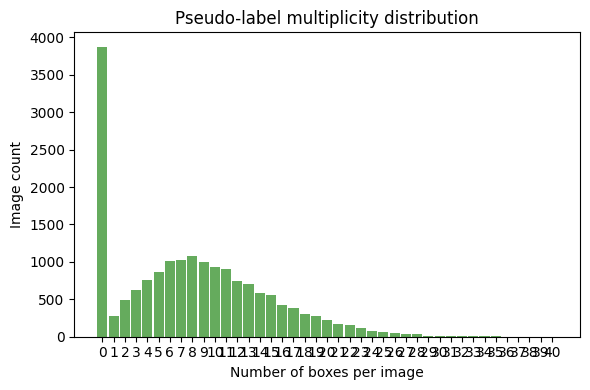

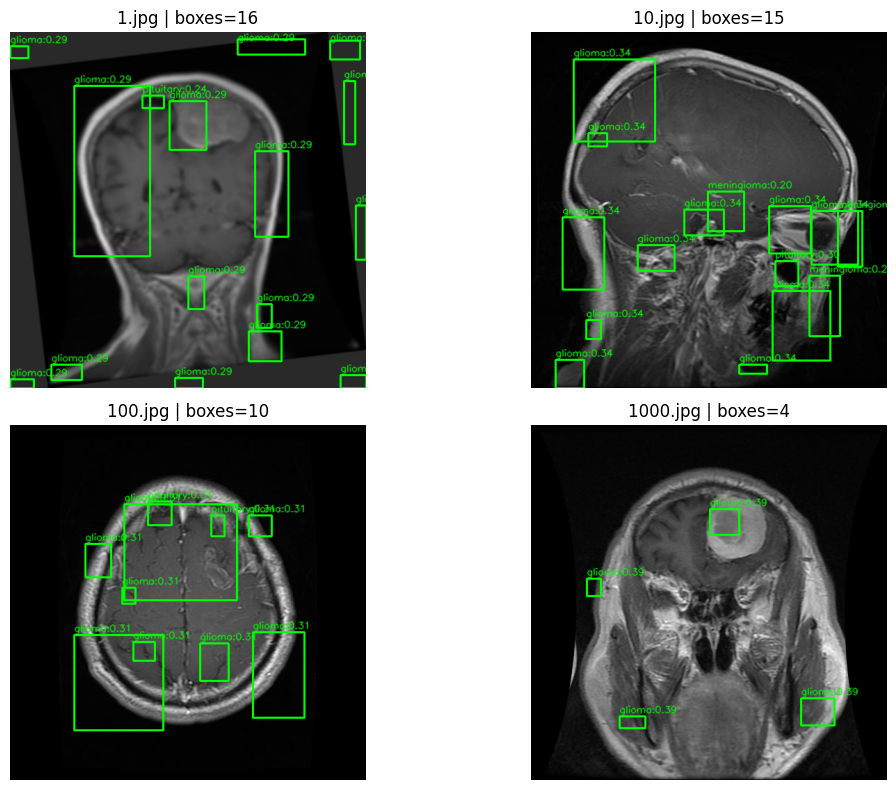

In [ ]:
labels_per_image = np.array(labels_per_image, dtype=np.int32)
if len(labels_per_image) > 0:
    print("Images with 0 boxes:", int((labels_per_image == 0).sum()))
    print("Images with 1 box:", int((labels_per_image == 1).sum()))
    print("Images with 2+ boxes:", int((labels_per_image >= 2).sum()))

    plt.figure(figsize=(6, 4))
    bins = np.arange(0, labels_per_image.max() + 2) - 0.5
    plt.hist(labels_per_image, bins=bins, color="#54a24b", alpha=0.9, rwidth=0.9)
    plt.xticks(range(int(labels_per_image.max()) + 1))
    plt.xlabel("Number of boxes per image")
    plt.ylabel("Image count")
    plt.title("Pseudo-label multiplicity distribution")
    plt.tight_layout()
    plt.show()

def draw_annotations_on_image(img_path, anns):
    bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if bgr is None:
        return None
    for ann in anns:
        x1, y1, x2, y2 = ann["box"]
        cls = ann["class_name"]
        score = ann["score"]
        cv2.rectangle(bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            bgr,
            f"{cls}:{score:.2f}",
            (x1, max(12, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

examples_shown = 0
plt.figure(figsize=(12, 8))
for rec in annotations:
    if len(rec["annotations"]) == 0:
        continue
    img_path = ROOT / rec["image_path"]
    vis = draw_annotations_on_image(img_path, rec["annotations"])
    if vis is None:
        continue
    examples_shown += 1
    plt.subplot(2, 2, examples_shown)
    plt.imshow(vis)
    plt.title(f"{Path(rec['image_path']).name} | boxes={len(rec['annotations'])}")
    plt.axis("off")
    if examples_shown == 4:
        break

if examples_shown > 0:
    plt.tight_layout()
    plt.show()
else:
    print("No positive pseudo-label examples to preview.")